<a href="https://colab.research.google.com/github/marciacastro03/projeto_07-Dossi-Exodus-Crise-de-Talentos-e-Discrimina-o/blob/main/etl_historico_promocoes02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`BLOCO 0 — SETUP E IMPORTAÇÕES`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")


CORES = {
    "M": "#2196F3",      # azul masculino
    "F": "#E91E63",      # rosa feminino
    "alert": "#FF5722",  # laranja alerta
    "ok": "#4CAF50",     # verde ok
    "bg": "#FAFAFA",
}

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": CORES["bg"]})

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


` BLOCO 1 — CARGA, LIMPEZA E ENGENHARIA DE FEATURES  (M1 + M2)`

In [12]:
df_historico_promocoes = pd.read_csv("/content/projeto_07_historico_promocoes (1).csv")

print(f"Shape original: {df_historico_promocoes.shape}")
print(df_historico_promocoes.head(10))

# ── 1.2  Tipos e strings

df_historico_promocoes["data_promocao"] = pd.to_datetime(df_historico_promocoes["data_promocao"])

# Normaliza strings: remove espaços extras, padroniza caixa onde faz sentido
for col in ["sexo", "departamento", "cargo_anterior", "cargo_novo"]:
    df_historico_promocoes[col] = df_historico_promocoes[col].str.strip()

# Converte colunas categóricas (economiza memória e agiliza groupby)
for col in ["sexo", "departamento", "cargo_anterior", "cargo_novo"]:
    df_historico_promocoes[col] = df_historico_promocoes[col].astype("category")

# ── 1.3  Nulos e duplicatas
def resumo_qualidade(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    M1 — Função de qualidade de dados.
    Retorna DataFrame com: tipo, nulos, % nulos, únicos, exemplo.
    Útil para auditar qualquer dataset de RH.
    """
    resumo = pd.DataFrame({
        "tipo":      dataframe.dtypes,
        "nulos":     dataframe.isnull().sum(),
        "pct_nulos": (dataframe.isnull().mean() * 100).round(2),
        "unicos":    dataframe.nunique(),
        "exemplo":   dataframe.iloc[0],
    })
    return resumo

print("\n📋 Relatório de Qualidade:")
print(resumo_qualidade(df_historico_promocoes).to_string())
print(f"\n🔁 Duplicatas: {df_historico_promocoes.duplicated().sum()}")

# ── 1.4  Outliers via IQR

def detectar_outliers_iqr(serie: pd.Series, label: str = "") -> dict:
    """
    M1 — Detecta outliers usando regra de Tukey (1.5 × IQR).
    Retorna dicionário com limites e índices dos outliers.
    """
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR    = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"  {label}: {len(outliers)} outliers | limites [{lim_inf:.1f}, {lim_sup:.1f}]")
    return {"inf": lim_inf, "sup": lim_sup, "indices": outliers.index.tolist()}

print("\n🔎 Detecção de Outliers (IQR):")
for col in ["meses_no_cargo_anterior", "aumento_percentual", "salario_anterior"]:
    detectar_outliers_iqr(df_historico_promocoes[col], col)

# → Outliers são mantidos: representam casos reais (promoções muito rápidas ou lentas)

# ── 1.5  Engenharia de Features

HIERARQUIA = {
    "Júnior": 1, "Pleno": 2, "Sênior": 3,
    "Coordenador": 4, "Gerente": 5, "Diretor": 6
}

def nivel_para_int(cargo: str) -> int:
    """M1 — Converte string de cargo para inteiro ordinal."""
    return HIERARQUIA.get(cargo, 0)

df_historico_promocoes["nivel_anterior"] = df_historico_promocoes["cargo_anterior"].astype(str).map(nivel_para_int)
df_historico_promocoes["nivel_novo"]     = df_historico_promocoes["cargo_novo"].astype(str).map(nivel_para_int)
df_historico_promocoes["salto_nivel"]    = df_historico_promocoes["nivel_novo"] - df_historico_promocoes["nivel_anterior"]
df_historico_promocoes["aumento_real"]   = df_historico_promocoes["salario_novo"] - df_historico_promocoes["salario_anterior"]
df_historico_promocoes["ano_promocao"]   = df_historico_promocoes["data_promocao"].dt.year

# Faixas de tempo no cargo (para análise de coorte)
bins   = [0, 18, 30, 42, 999]
labels = ["< 18 meses", "18–30 meses", "30–42 meses", "> 42 meses"]
df_historico_promocoes["faixa_meses"] = pd.cut(df_historico_promocoes["meses_no_cargo_anterior"], bins=bins, labels=labels)

print("\n✅ Features criadas:")
print(df_historico_promocoes[["nivel_anterior","nivel_novo","salto_nivel","aumento_real","faixa_meses"]].head())


Shape original: (600, 11)
  funcionario_id sexo departamento cargo_anterior   cargo_novo data_promocao  \
0      FUN-00705    F      Produto         Sênior  Coordenador    2021-08-02   
1      FUN-00334    M      Produto         Júnior        Pleno    2021-01-13   
2      FUN-00380    M    Marketing          Pleno       Sênior    2024-01-24   
3      FUN-00953    F           RH         Júnior        Pleno    2022-09-04   
4      FUN-00463    M   Financeiro         Sênior  Coordenador    2023-04-20   
5      FUN-00924    M      Suporte         Júnior        Pleno    2024-08-06   
6      FUN-00670    M           RH          Pleno       Sênior    2023-04-02   
7      FUN-01179    F    Marketing         Júnior        Pleno    2024-11-08   
8      FUN-01140    M       Vendas          Pleno       Sênior    2023-03-04   
9      FUN-00395    M    Operações         Sênior  Coordenador    2022-08-19   

   meses_no_cargo_anterior  salario_anterior  salario_novo  \
0                       36     

`BLOCO 2 — ANÁLISE UNIVARIADA  (M3: countplot, histograma)`

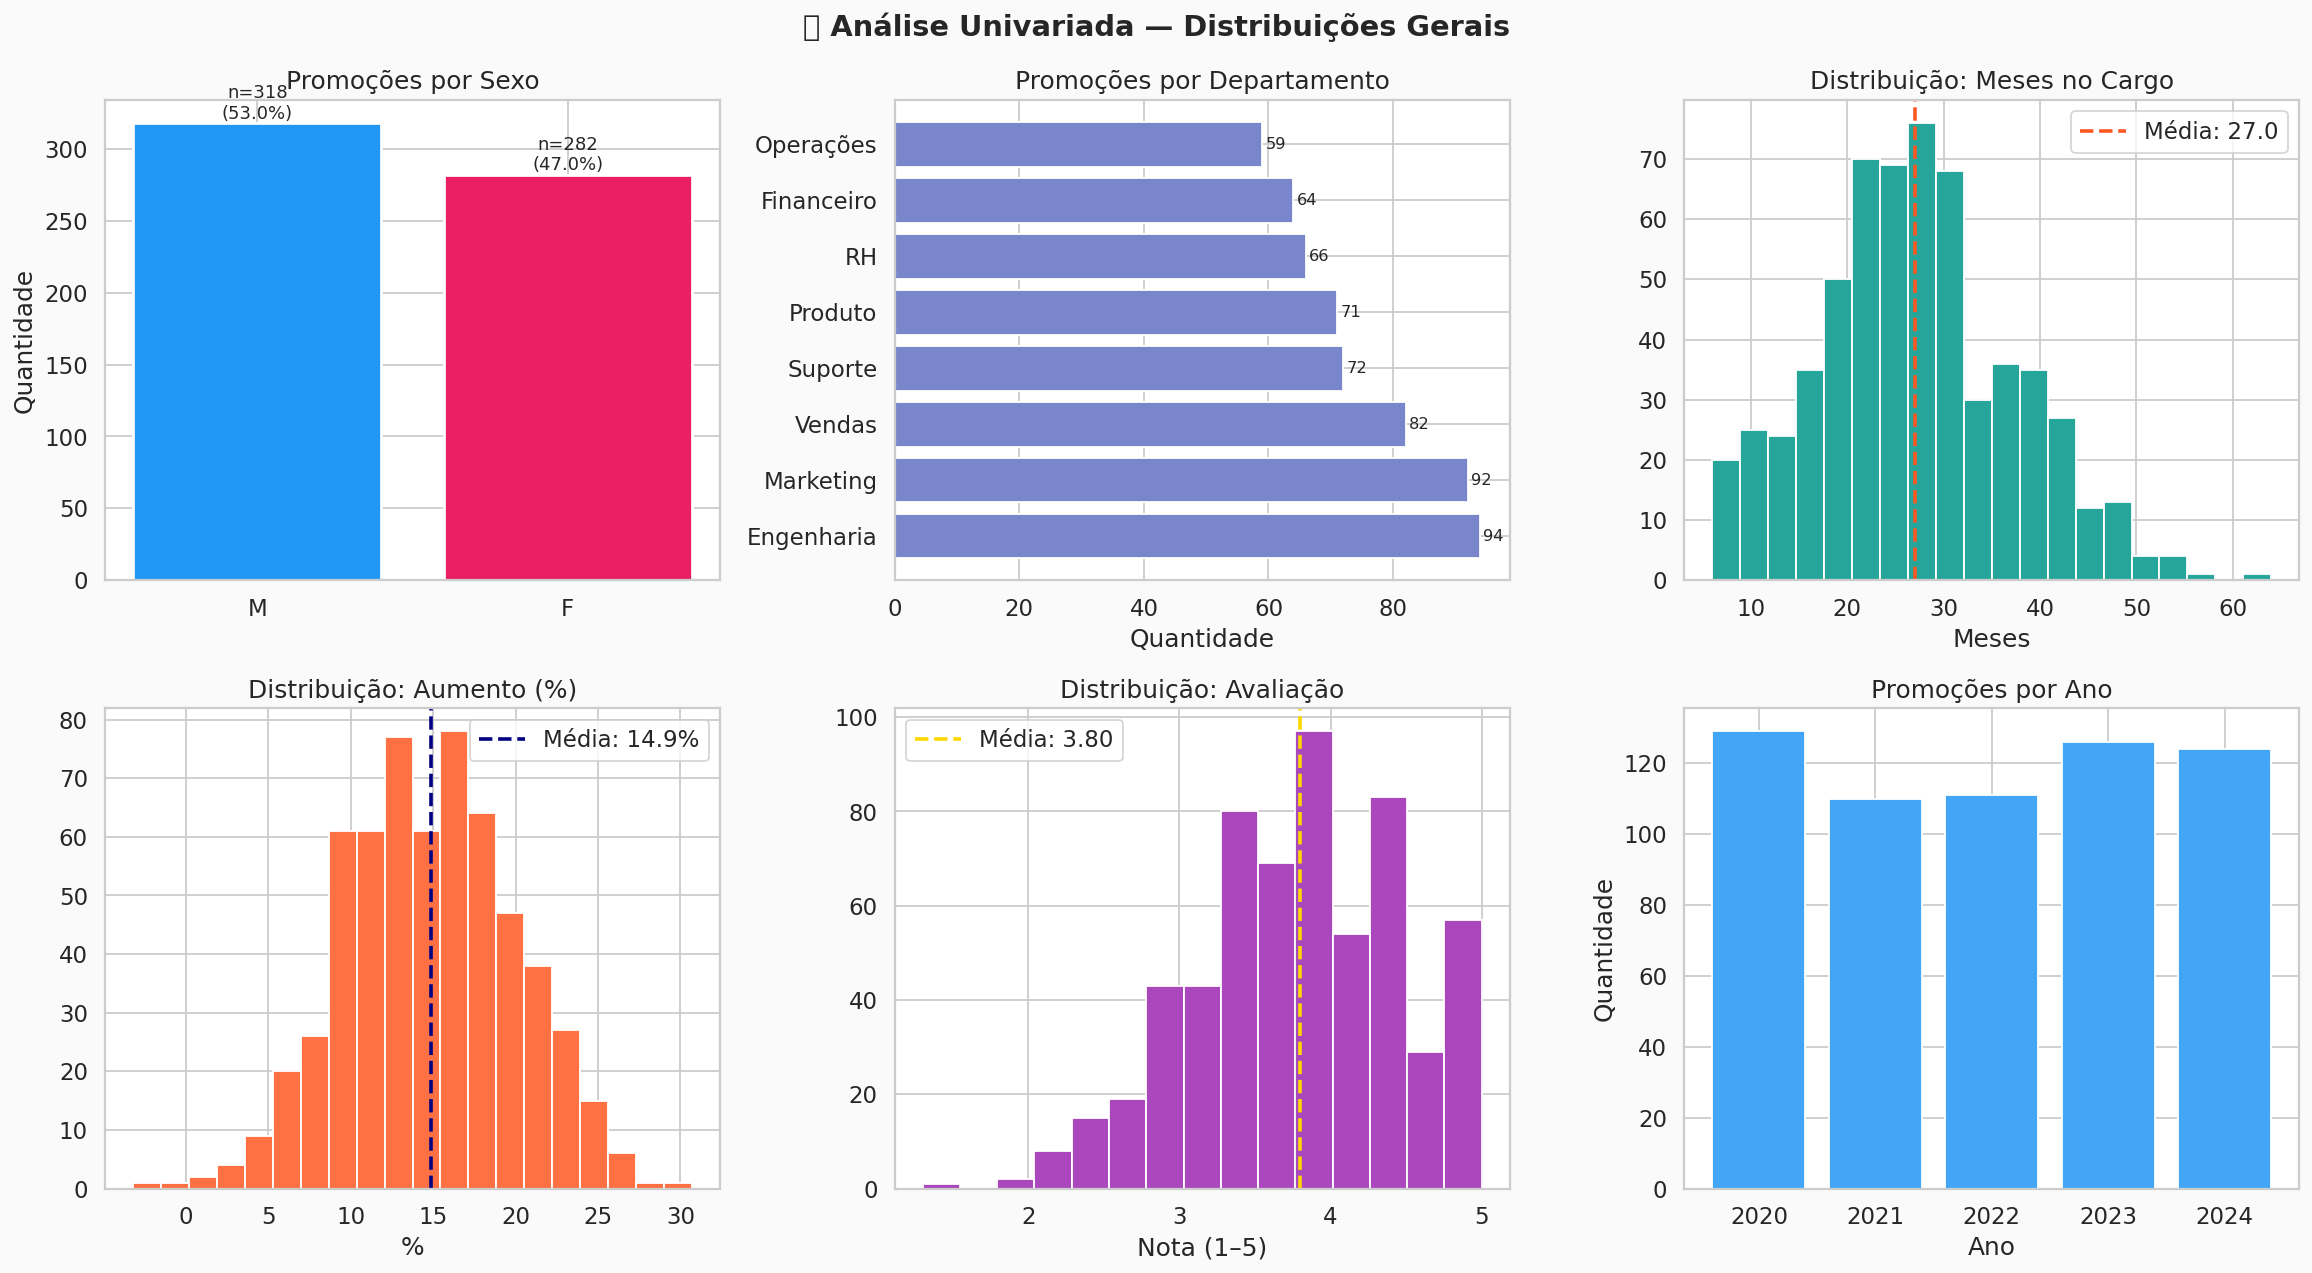

💾 Gráfico salvo: bloco2_univariada.png


In [17]:
# @title
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("📊 Análise Univariada — Distribuições Gerais", fontsize=16, fontweight="bold")

# 2.1 Distribuição por Sexo
ax = axes[0, 0]
contagem_sexo = df_historico_promocoes["sexo"].value_counts()
bars = ax.bar(contagem_sexo.index, contagem_sexo.values,
              color=[CORES["M"], CORES["F"]], edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, contagem_sexo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"n={v}\n({v/len(df_historico_promocoes)*100:.1f}%)", ha="center", fontsize=10)
ax.set_title("Promoções por Sexo")
ax.set_ylabel("Quantidade")

# 2.2 Distribuição por Departamento
ax = axes[0, 1]
contagem_dep = df_historico_promocoes["departamento"].value_counts()
ax.barh(contagem_dep.index, contagem_dep.values, color="#7986CB", edgecolor="white")
ax.set_title("Promoções por Departamento")
ax.set_xlabel("Quantidade")
for i, v in enumerate(contagem_dep.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)

# 2.3 Histograma: Meses no Cargo Anterior
ax = axes[0, 2]
ax.hist(df_historico_promocoes["meses_no_cargo_anterior"], bins=20, color="#26A69A", edgecolor="white")
ax.axvline(df_historico_promocoes["meses_no_cargo_anterior"].mean(), color=CORES["alert"],
           linestyle="--", linewidth=2, label=f"Média: {df_historico_promocoes['meses_no_cargo_anterior'].mean():.1f}")
ax.legend()
ax.set_title("Distribuição: Meses no Cargo")
ax.set_xlabel("Meses")

# 2.4 Distribuição do Aumento %
ax = axes[1, 0]
ax.hist(df_historico_promocoes["aumento_percentual"], bins=20, color="#FF7043", edgecolor="white")
ax.axvline(df_historico_promocoes["aumento_percentual"].mean(), color="navy",
           linestyle="--", linewidth=2, label=f"Média: {df_historico_promocoes['aumento_percentual'].mean():.1f}%")
ax.legend()
ax.set_title("Distribuição: Aumento (%)")
ax.set_xlabel("%")

# 2.5 Distribuição da Avaliação
ax = axes[1, 1]
ax.hist(df_historico_promocoes["avaliacao_no_momento"], bins=15, color="#AB47BC", edgecolor="white")
ax.axvline(df_historico_promocoes["avaliacao_no_momento"].mean(), color="gold",
           linestyle="--", linewidth=2, label=f"Média: {df_historico_promocoes['avaliacao_no_momento'].mean():.2f}")
ax.legend()
ax.set_title("Distribuição: Avaliação")
ax.set_xlabel("Nota (1–5)")

# 2.6 Promoções por Ano
ax = axes[1, 2]
por_ano = df_historico_promocoes["ano_promocao"].value_counts().sort_index()
ax.bar(por_ano.index.astype(str), por_ano.values, color="#42A5F5", edgecolor="white")
ax.set_title("Promoções por Ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade")

plt.tight_layout()
plt.savefig("bloco2_univariada.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico salvo: bloco2_univariada.png")

`BLOCO 3 — GÊNERO × TEMPO DE PROMOÇÃO  (M2 + M3)`

In [20]:
# HIPÓTESE: Mulheres esperam ~40% mais meses para serem promovidas.
# MÉTODO:
  # 1. groupby sexo → média, mediana, std
  # 2. Boxplot e Violinplot comparativos
  # 3. Teste estatístico Mann-Whitney U (não paramétrico, pois distribuição pode ser assimétrica)
  #4. Análise por departamento para identificar onde a disparidade é maior

# ── 3.1  Estatísticas descritivas

stats_genero = df_historico_promocoes.groupby("sexo", observed=True)["meses_no_cargo_anterior"].agg(
    n="count",
    media="mean",
    mediana="median",
    desvio_padrao="std",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
).round(2)

print("=" * 60)
print("📊 TEMPO MÉDIO ATÉ PROMOÇÃO POR SEXO")
print("=" * 60)
print(stats_genero)

media_M = stats_genero.loc["M", "media"]
media_F = stats_genero.loc["F", "media"]
diferenca_pct = ((media_F - media_M) / media_M) * 100
print(f"\n  Homens (M): {media_M:.1f} meses em média")
print(f"  Mulheres (F): {media_F:.1f} meses em média")
print(f"  📌 Diferença: +{diferenca_pct:.1f}% a mais para mulheres")




📊 TEMPO MÉDIO ATÉ PROMOÇÃO POR SEXO
        n  media  mediana  desvio_padrao   p25   p75
sexo                                                
F     282  31.71     31.0          10.50  24.0  40.0
M     318  22.87     23.0           8.07  17.0  29.0

  Homens (M): 22.9 meses em média
  Mulheres (F): 31.7 meses em média
  📌 Diferença: +38.7% a mais para mulheres


In [23]:
# ── 3.2  Teste estatístico (Mann-Whitney U)

"""
Usamos Mann-Whitney (não paramétrico) porque:
  - Distribuições podem não ser normais
  - Mais robusto a outliers
  - Adequado para comparação de duas amostras independentes
H0: não há diferença entre as distribuições de tempo (M vs F)
Ha: há diferença (bilateral)
"""
grupo_M = df_historico_promocoes[df_historico_promocoes["sexo"] == "M"]["meses_no_cargo_anterior"]
grupo_F = df_historico_promocoes[df_historico_promocoes["sexo"] == "F"]["meses_no_cargo_anterior"]

stat_mw, p_valor_mw = stats.mannwhitneyu(grupo_F, grupo_M, alternative="two-sided")
print(f"\n🔬 Teste Mann-Whitney U:")
print(f"   U = {stat_mw:.1f}, p-valor = {p_valor_mw:.4f}")
if p_valor_mw < 0.05:
    print("   ✅ Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)")
    print("   → A disparidade de gênero no tempo de promoção NÃO é aleatória.")
else:
    print("   ⚠️  Diferença NÃO é estatisticamente significativa (p ≥ 0.05)")


🔬 Teste Mann-Whitney U:
   U = 66644.0, p-valor = 0.0000
   ✅ Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)
   → A disparidade de gênero no tempo de promoção NÃO é aleatória.


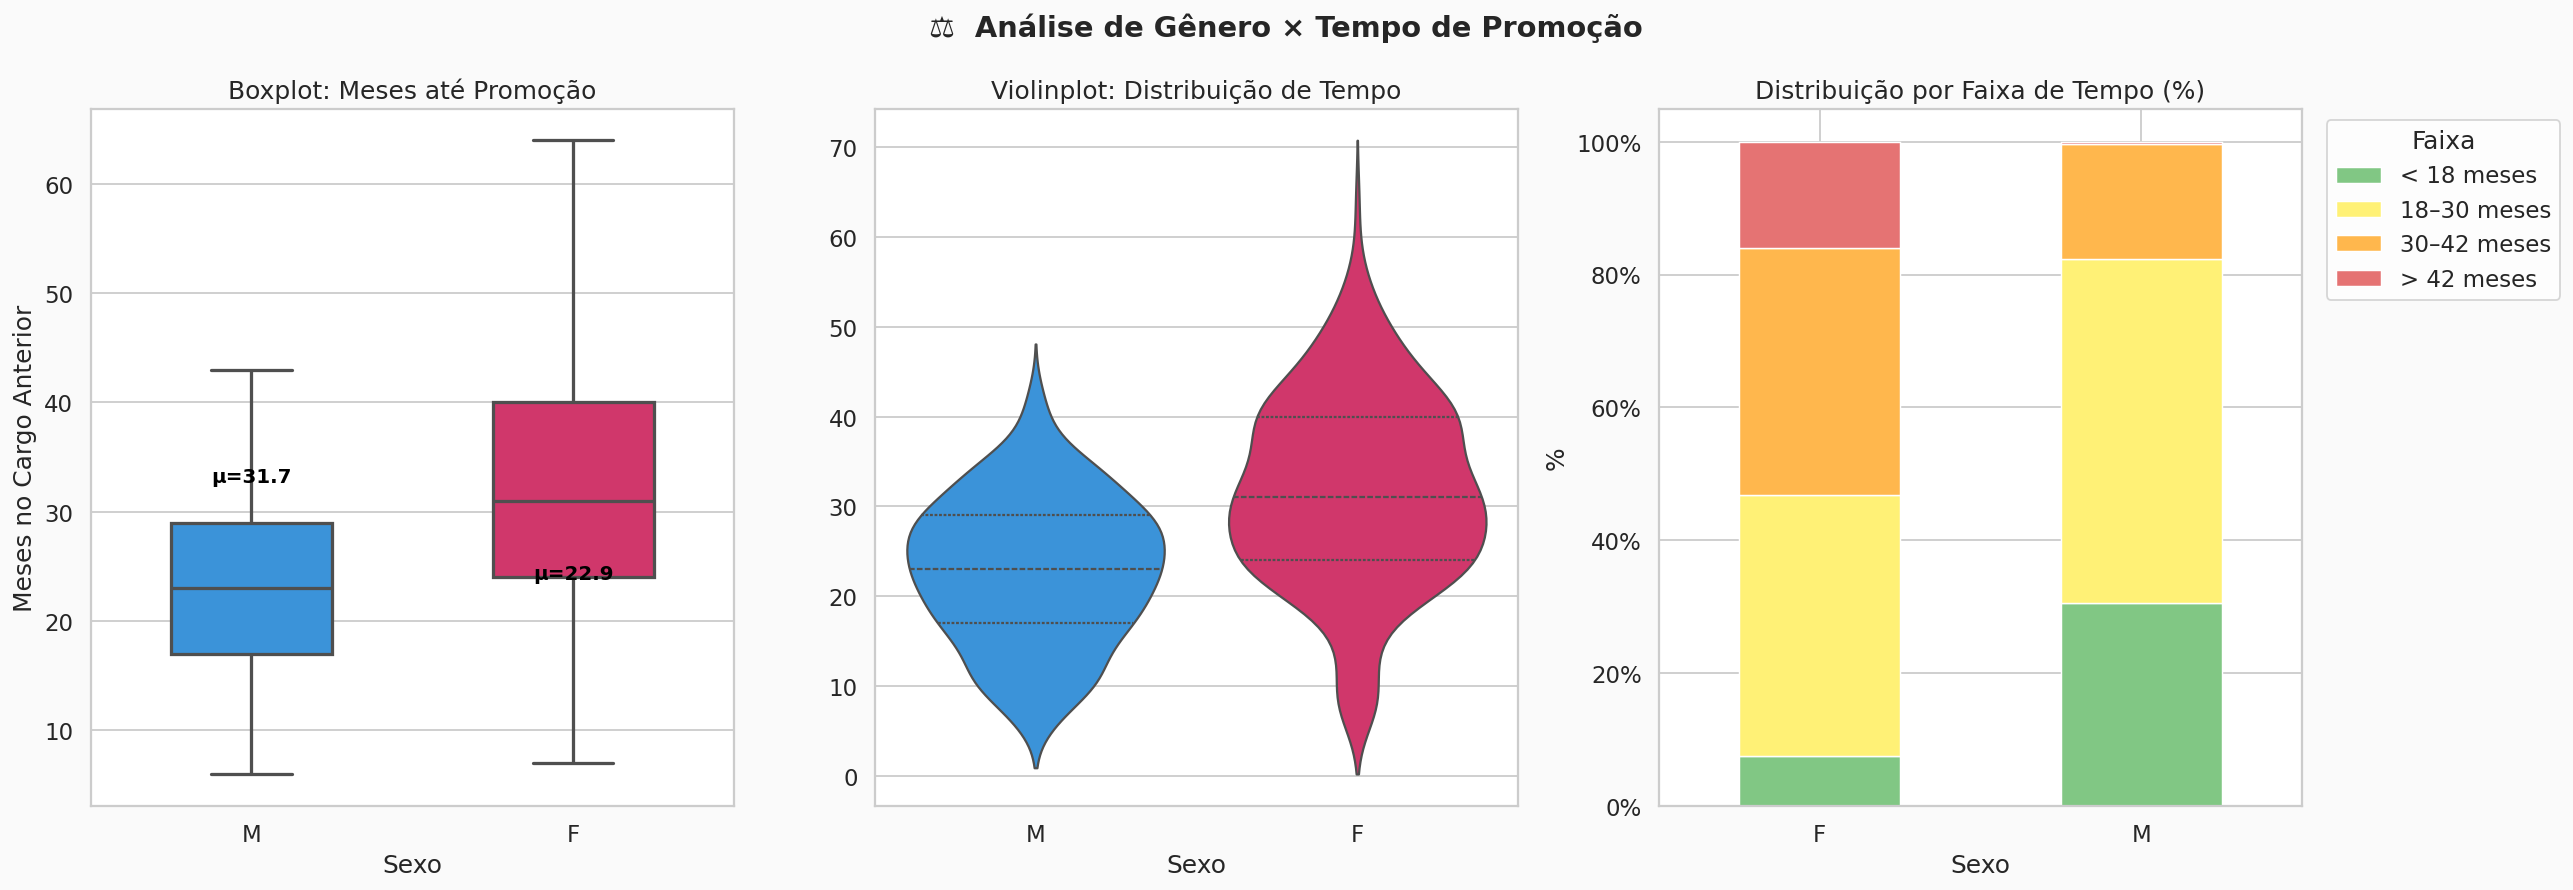

💾 Gráfico salvo: bloco3_genero_tempo.png


In [24]:
# ── 3.3  Visualizações comparativas

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("⚖️  Análise de Gênero × Tempo de Promoção", fontsize=16, fontweight="bold")

# Boxplot
ax = axes[0]
sns.boxplot(data=df_historico_promocoes, x="sexo", y="meses_no_cargo_anterior",
            palette={"M": CORES["M"], "F": CORES["F"]},
            width=0.5, linewidth=1.8, ax=ax, order=["M", "F"])
ax.set_title("Boxplot: Meses até Promoção")
ax.set_xlabel("Sexo")
ax.set_ylabel("Meses no Cargo Anterior")
# Anotação com médias
for i, (sexo, grp) in enumerate(df_historico_promocoes.groupby("sexo", observed=True)):
    ax.text(i, grp["meses_no_cargo_anterior"].mean() + 1,
            f"μ={grp['meses_no_cargo_anterior'].mean():.1f}",
            ha="center", color="black", fontweight="bold", fontsize=11)

# Violinplot
ax = axes[1]
sns.violinplot(data=df_historico_promocoes, x="sexo", y="meses_no_cargo_anterior",
               palette={"M": CORES["M"], "F": CORES["F"]},
               inner="quartile", order=["M", "F"], ax=ax)
ax.set_title("Violinplot: Distribuição de Tempo")
ax.set_xlabel("Sexo")
ax.set_ylabel("")

# Stacked bar: faixas de meses por sexo (normalizado)
ax = axes[2]
tabela_faixa = (
    df_historico_promocoes.groupby(["sexo", "faixa_meses"], observed=True)
      .size()
      .unstack(fill_value=0)
)
tabela_faixa_pct = tabela_faixa.div(tabela_faixa.sum(axis=1), axis=0) * 100

cores_faixas = ["#81C784", "#FFF176", "#FFB74D", "#E57373"]
tabela_faixa_pct.plot(kind="bar", stacked=True, ax=ax,
                       color=cores_faixas, edgecolor="white", linewidth=0.8)
ax.set_title("Distribuição por Faixa de Tempo (%)")
ax.set_xlabel("Sexo")
ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="Faixa", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("bloco3_genero_tempo.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico salvo: bloco3_genero_tempo.png")




📊 DISPARIDADE POR DEPARTAMENTO (meses médios M vs F)
sexo              F      M  diferenca_abs  diferenca_pct
departamento                                            
Financeiro    31.83  20.68          11.15           53.9
Vendas        31.77  20.64          11.13           53.9
RH            33.00  22.95          10.05           43.8
Marketing     31.61  22.93           8.67           37.8
Engenharia    31.95  23.71           8.25           34.8
Operações     31.57  23.48           8.09           34.4
Suporte       31.05  23.71           7.34           31.0
Produto       31.24  24.71           6.53           26.4


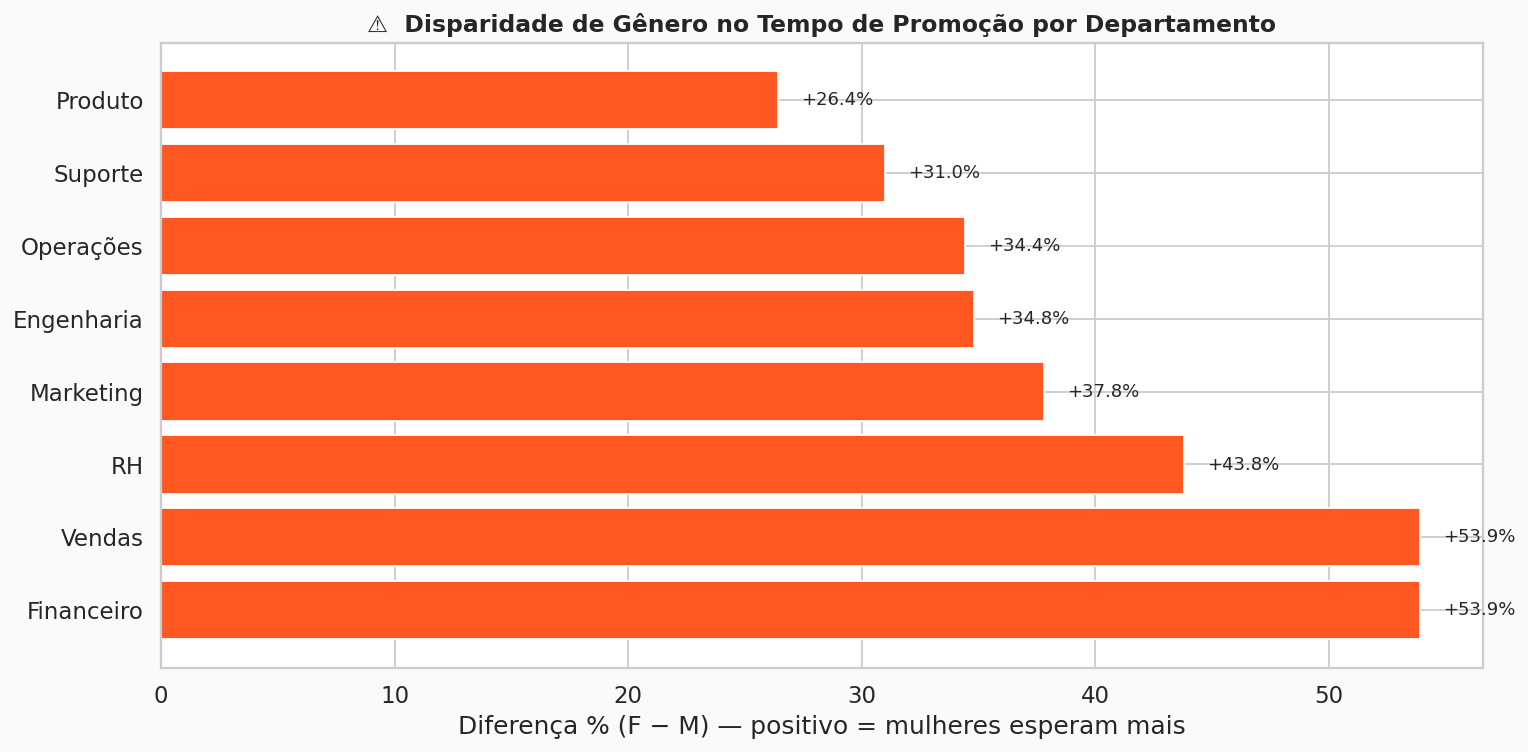

💾 Gráfico salvo: bloco3b_disparidade_dep.png


In [25]:
# ── 3.4  Disparidade por departamento

"""
M2 — groupby com múltiplas agregações:
Identifica em quais departamentos a disparidade de gênero é maior.
"""
disparidade_dep = (
    df_historico_promocoes.groupby(["departamento", "sexo"], observed=True)["meses_no_cargo_anterior"]
      .mean()
      .unstack()
      .assign(diferenca_abs=lambda x: x["F"] - x["M"],
              diferenca_pct=lambda x: ((x["F"] - x["M"]) / x["M"] * 100).round(1))
      .sort_values("diferenca_pct", ascending=False)
      .round(2)
)

print("\n" + "=" * 65)
print("📊 DISPARIDADE POR DEPARTAMENTO (meses médios M vs F)")
print("=" * 65)
print(disparidade_dep.to_string())

# Gráfico de barras: diferença % por departamento
fig, ax = plt.subplots(figsize=(12, 6))
cores_barras = [CORES["alert"] if v > 0 else CORES["ok"]
                for v in disparidade_dep["diferenca_pct"]]
barras = ax.barh(disparidade_dep.index.astype(str),
                  disparidade_dep["diferenca_pct"],
                  color=cores_barras, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Diferença % (F − M) — positivo = mulheres esperam mais")
ax.set_title("⚠️  Disparidade de Gênero no Tempo de Promoção por Departamento",
             fontsize=13, fontweight="bold")
for bar, v in zip(barras, disparidade_dep["diferenca_pct"]):
    ax.text(v + (1 if v >= 0 else -1), bar.get_y() + bar.get_height()/2,
            f"{v:+.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("bloco3b_disparidade_dep.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico salvo: bloco3b_disparidade_dep.png")

`BLOCO 4 — ANÁLISE POR DEPARTAMENTO (sinal de gestor tóxico)  (M2 + M3)`

🚨 ÍNDICE DE ATENÇÃO POR DEPARTAMENTO (maior = mais problemático)
              n_promocoes  avaliacao_media  aumento_medio  meses_medio  pct_mulheres  indice_atencao
departamento                                                                                        
Marketing              92             3.72          14.79        27.27         50.00           0.726
Operações              59             3.81          14.35        27.32         47.46           0.345
Suporte                72             3.81          14.48        27.49         51.39           0.345
Engenharia             94             3.87          14.09        27.48         45.74           0.129
Produto                71             3.79          15.40        27.75         46.48           0.073
Financeiro             64             3.75          15.37        26.95         56.25           0.028
RH                     66             3.82          14.85        26.61         36.36          -0.333
Vendas                 82 

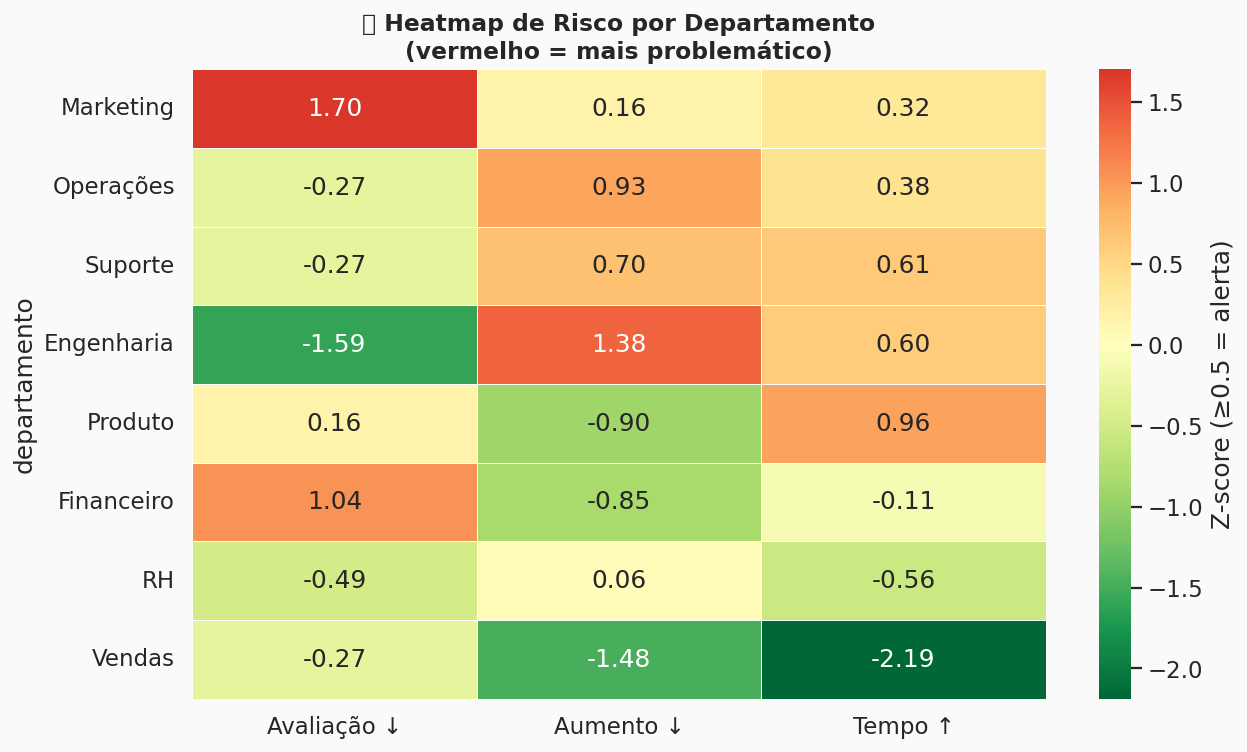

💾 Gráfico salvo: bloco4_heatmap_dep.png


In [26]:
"""
Indicadores de alerta por departamento:
  1. Avaliação média menor que o geral (possível gestor que avalia mal)
  2. Aumento médio menor (possível favorecimento ou punição)
  3. Tempo médio de promoção muito alto (represamento de carreira)

Combinando esses três eixos, calculamos um "índice de atenção".
"""

def calcular_zscore(serie: pd.Series) -> pd.Series:
    """
    M1 — Z-score de uma série.
    Permite comparar variáveis em escalas diferentes no mesmo índice.
    """
    return (serie - serie.mean()) / serie.std()

perfil_dep = df_historico_promocoes.groupby("departamento", observed=True).agg(
    n_promocoes=("funcionario_id", "count"),
    avaliacao_media=("avaliacao_no_momento", "mean"),
    aumento_medio=("aumento_percentual", "mean"),
    meses_medio=("meses_no_cargo_anterior", "mean"),
    pct_mulheres=("sexo", lambda x: (x == "F").mean() * 100),
).round(2)

# Z-scores (invertemos meses_medio e subtraímos avaliação e aumento para
# que valores mais altos = mais problemático)
perfil_dep["z_avaliacao"] = -calcular_zscore(perfil_dep["avaliacao_media"])
perfil_dep["z_aumento"]   = -calcular_zscore(perfil_dep["aumento_medio"])
perfil_dep["z_meses"]     =  calcular_zscore(perfil_dep["meses_medio"])

# Índice de Atenção = média dos z-scores de risco
perfil_dep["indice_atencao"] = (
    perfil_dep[["z_avaliacao", "z_aumento", "z_meses"]].mean(axis=1)
).round(3)
perfil_dep = perfil_dep.sort_values("indice_atencao", ascending=False)

print("=" * 70)
print("🚨 ÍNDICE DE ATENÇÃO POR DEPARTAMENTO (maior = mais problemático)")
print("=" * 70)
print(perfil_dep[["n_promocoes","avaliacao_media","aumento_medio",
                   "meses_medio","pct_mulheres","indice_atencao"]].to_string())

# Heatmap dos z-scores
fig, ax = plt.subplots(figsize=(10, 6))
heatmap_data = perfil_dep[["z_avaliacao", "z_aumento", "z_meses"]].rename(columns={
    "z_avaliacao": "Avaliação ↓",
    "z_aumento":   "Aumento ↓",
    "z_meses":     "Tempo ↑",
})
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"label": "Z-score (≥0.5 = alerta)"})
ax.set_title("🔥 Heatmap de Risco por Departamento\n(vermelho = mais problemático)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("bloco4_heatmap_dep.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico salvo: bloco4_heatmap_dep.png")

`BLOCO 5 — EQUIDADE SALARIAL POR GÊNERO  (M2 + M3)`

💰 EQUIDADE SALARIAL — VISÃO GERAL
      salario_ant_medio  salario_nov_medio  aumento_pct_medio  \
sexo                                                            
F               7271.25            8345.02              14.63   
M               7787.32            8953.98              15.08   

      aumento_real_medio  
sexo                      
F                1073.77  
M                1166.66  

  Razão salarial (F/M) — ANTES da promoção: 0.934  → mulheres ganham -6.6% menos
  Razão salarial (F/M) — APÓS  a promoção: 0.932  → mulheres ganham -6.8% menos

📊 Razão Salarial F/M por Cargo (antes da promoção):
sexo                       F             M  razao_F_M
cargo_anterior                                       
Júnior           3923.421019   4116.562347      0.953
Pleno            6944.655517   6995.617476      0.993
Coordenador     13881.485217  13804.365862      1.006
Sênior          10989.137031  10818.983977      1.016


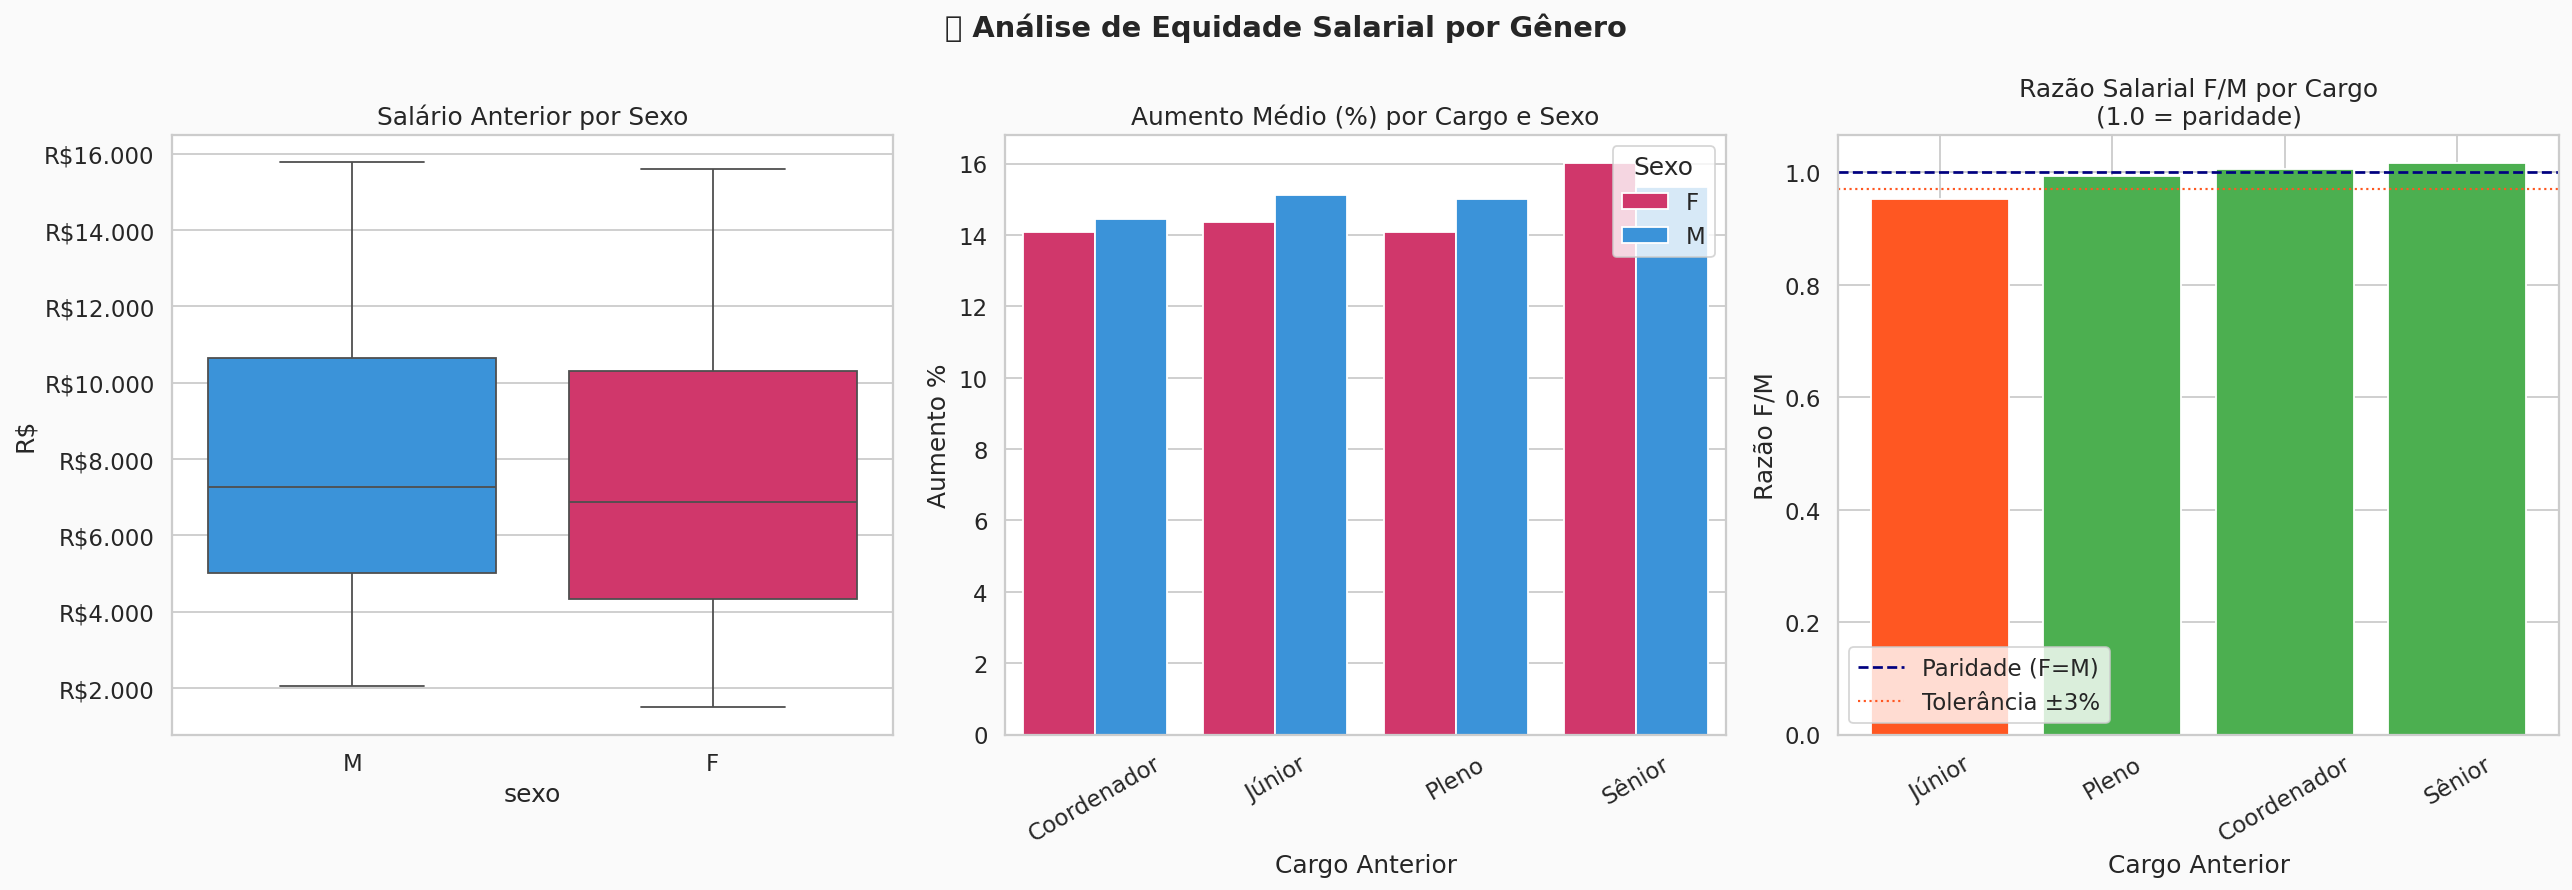

💾 Gráfico salvo: bloco5_equidade_salarial.png


In [27]:
"""
Compara salário anterior e novo, aumento % e aumento real entre homens e mulheres,
controlando pelo nível de cargo (para eliminar confusão de cargo).

Análise de Coorte Simplificada: para cada combinação departamento × nível,
calcula a razão salarial F/M.
"""

# ── 5.1  Comparação geral
print("=" * 60)
print("💰 EQUIDADE SALARIAL — VISÃO GERAL")
print("=" * 60)
eq_geral = df_historico_promocoes.groupby("sexo", observed=True).agg(
    salario_ant_medio=("salario_anterior", "mean"),
    salario_nov_medio=("salario_novo", "mean"),
    aumento_pct_medio=("aumento_percentual", "mean"),
    aumento_real_medio=("aumento_real", "mean"),
).round(2)
print(eq_geral)

razao_sal_ant = eq_geral.loc["F","salario_ant_medio"] / eq_geral.loc["M","salario_ant_medio"]
razao_sal_nov = eq_geral.loc["F","salario_nov_medio"] / eq_geral.loc["M","salario_nov_medio"]
print(f"\n  Razão salarial (F/M) — ANTES da promoção: {razao_sal_ant:.3f}  → mulheres ganham {(razao_sal_ant-1)*100:.1f}% {'menos' if razao_sal_ant < 1 else 'mais'}")
print(f"  Razão salarial (F/M) — APÓS  a promoção: {razao_sal_nov:.3f}  → mulheres ganham {(razao_sal_nov-1)*100:.1f}% {'menos' if razao_sal_nov < 1 else 'mais'}")


# ── 5.2  Controlando pelo nível de cargo
"""
M2 — merge implícito via groupby: comparar salários controlando pelo cargo
evita o "viés de composição" (mulheres podem ser mais concentradas em cargos
de nível inferior, o que artificialmente rebaixaria a média salarial feminina).
"""
eq_cargo = (
    df_historico_promocoes.groupby(["cargo_anterior", "sexo"], observed=True)["salario_anterior"]
      .mean()
      .unstack()
      .assign(razao_F_M=lambda x: (x["F"] / x["M"]).round(3))
      .dropna()
      .sort_values("razao_F_M")
)
print("\n📊 Razão Salarial F/M por Cargo (antes da promoção):")
print(eq_cargo)

# ── 5.3  Visualizações salariais
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("💰 Análise de Equidade Salarial por Gênero", fontsize=16, fontweight="bold")

# Boxplot salário anterior por sexo
sns.boxplot(data=df_historico_promocoes, x="sexo", y="salario_anterior",
            palette={"M": CORES["M"], "F": CORES["F"]},
            order=["M", "F"], ax=axes[0])
axes[0].set_title("Salário Anterior por Sexo")
axes[0].set_ylabel("R$")
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"R${x:,.0f}".replace(",",".")))

# Aumento percentual por sexo e cargo (catplot como barplot no eixo)
eq_cargo_aumento = (
    df_historico_promocoes.groupby(["cargo_anterior", "sexo"], observed=True)["aumento_percentual"]
      .mean()
      .reset_index()
)
sns.barplot(data=eq_cargo_aumento, x="cargo_anterior", y="aumento_percentual",
            hue="sexo", palette={"M": CORES["M"], "F": CORES["F"]},
            ax=axes[1])
axes[1].set_title("Aumento Médio (%) por Cargo e Sexo")
axes[1].set_xlabel("Cargo Anterior")
axes[1].set_ylabel("Aumento %")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Sexo")

# Razão F/M por cargo — linha da paridade
ax = axes[2]
razoes = eq_cargo["razao_F_M"].reset_index()
cores_r = [CORES["alert"] if r < 0.97 else CORES["ok"] for r in razoes["razao_F_M"]]
ax.bar(razoes["cargo_anterior"].astype(str), razoes["razao_F_M"],
       color=cores_r, edgecolor="white")
ax.axhline(1.0, color="navy", linestyle="--", linewidth=1.5, label="Paridade (F=M)")
ax.axhline(0.97, color=CORES["alert"], linestyle=":", linewidth=1.2, label="Tolerância ±3%")
ax.set_title("Razão Salarial F/M por Cargo\n(1.0 = paridade)")
ax.set_ylabel("Razão F/M")
ax.set_xlabel("Cargo Anterior")
ax.tick_params(axis="x", rotation=30)
ax.legend()

plt.tight_layout()
plt.savefig("bloco5_equidade_salarial.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico salvo: bloco5_equidade_salarial.png")

`BLOCO 6 — SCORE DE RISCO DE TURNOVER  (M1 + M2)`

🚨 DISTRIBUIÇÃO DO RISCO DE TURNOVER
risco_turnover
MÉDIO    379
BAIXO    212
ALTO       9
Name: count, dtype: int64

  Score médio geral: 0.439
  Score médio — Homens: 0.414
  Score médio — Mulheres: 0.468

🔴 Top 10 funcionários com maior risco de turnover:
funcionario_id sexo departamento cargo_anterior  meses_no_cargo_anterior  avaliacao_no_momento  aumento_percentual  score_turnover risco_turnover
     FUN-01115    F    Operações          Pleno                       46                   1.3                 5.0          0.8464           ALTO
     FUN-00994    F    Marketing         Júnior                       54                   2.2                10.2          0.7643           ALTO
     FUN-01176    F      Suporte         Sênior                       41                   2.4                 7.8          0.6959           ALTO
     FUN-00623    F    Marketing         Júnior                       43                   2.3                10.9          0.6928           ALTO
     FUN-000

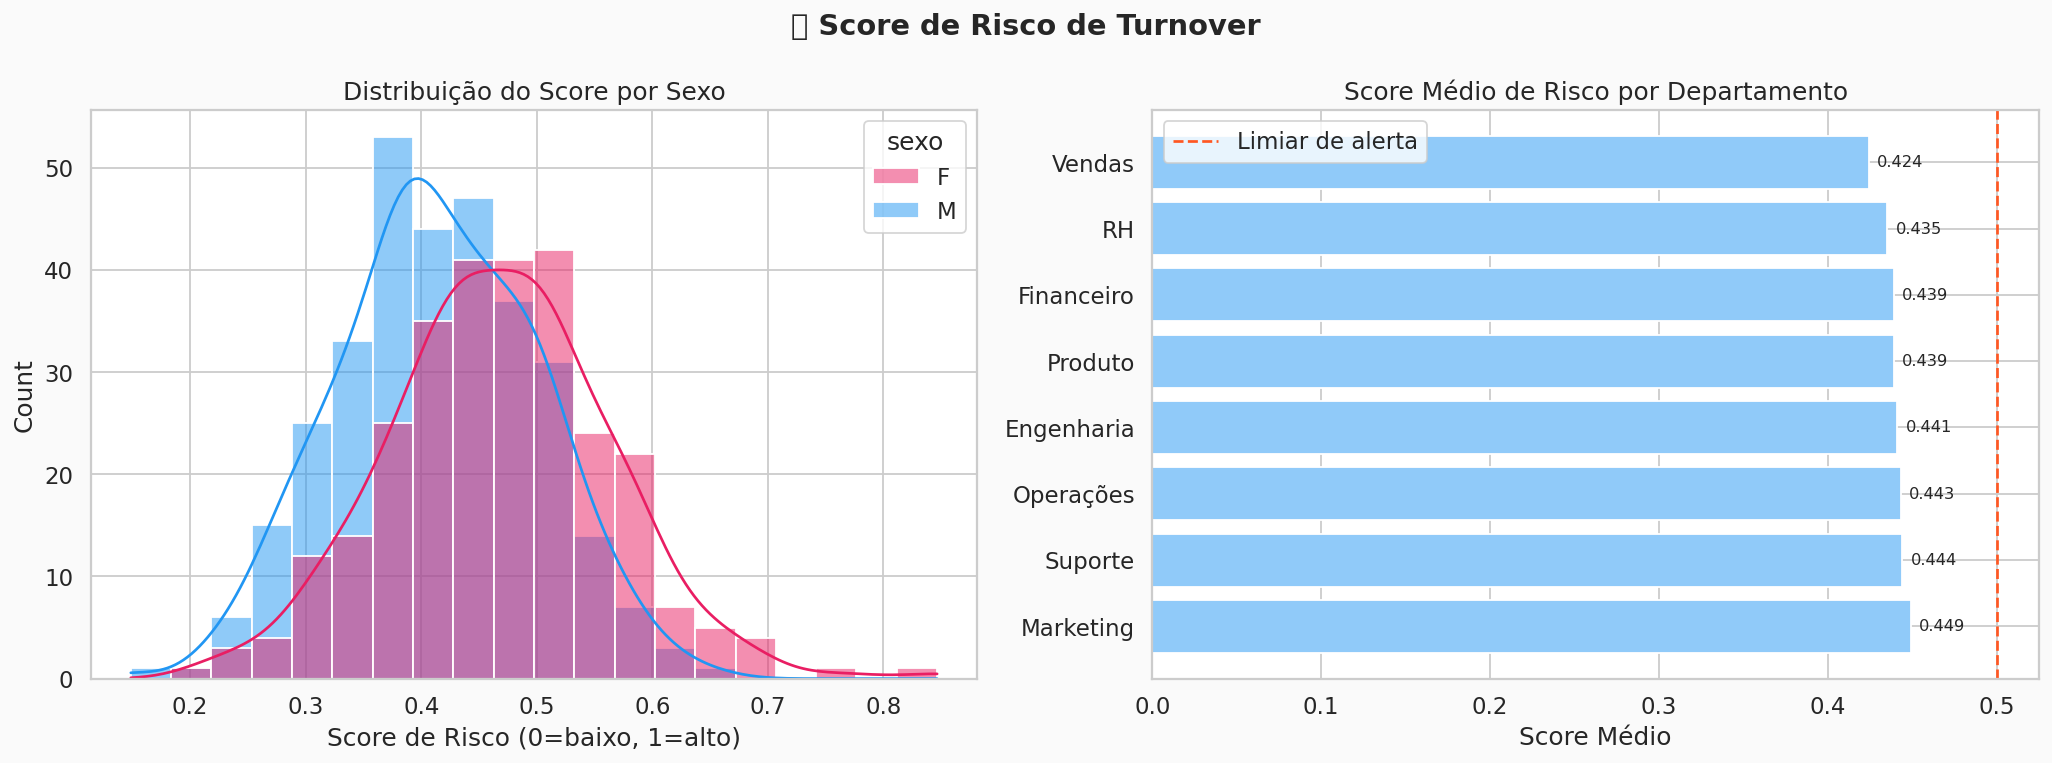

💾 Gráfico salvo: bloco6_score_turnover.png


In [30]:
"""
Calcula um score de risco de turnover para cada funcionário no histórico.
O score combina:
  • Tempo longo sem promoção    → aumenta risco
  • Avaliação baixa             → aumenta risco (desmotivação)
  • Aumento percentual baixo    → aumenta risco (remuneração insatisfatória)
  • Pequeno salto de nível      → aumenta risco (promoção pouco recompensadora)

Cada componente é normalizado 0–1 antes de compor o score.
"""

def normalizar_0_1(serie: pd.Series) -> pd.Series:
    """
    M1 — Normalização Min-Max.
    Converte qualquer série numérica para o intervalo [0, 1].
    """
    min_v, max_v = serie.min(), serie.max()
    if max_v == min_v:
        return pd.Series(np.zeros(len(serie)), index=serie.index)
    return (serie - min_v) / (max_v - min_v)

# Componentes do score (invertemos avaliação e aumento: maior → menor risco)
df_historico_promocoes["comp_meses"]    = normalizar_0_1(df_historico_promocoes["meses_no_cargo_anterior"])       # longo = risco
df_historico_promocoes["comp_avaliacao"]= 1 - normalizar_0_1(df_historico_promocoes["avaliacao_no_momento"])      # baixa = risco
df_historico_promocoes["comp_aumento"]  = 1 - normalizar_0_1(df_historico_promocoes["aumento_percentual"])        # baixo = risco
df_historico_promocoes["comp_salto"]    = 1 - normalizar_0_1(df_historico_promocoes["salto_nivel"].clip(lower=0)) # pequeno salto = risco

# Score composto — pesos iguais (podem ser ajustados pela VP de Pessoas)
PESOS = {"meses": 0.30, "avaliacao": 0.35, "aumento": 0.25, "salto": 0.10}
df_historico_promocoes["score_turnover"] = (
    PESOS["meses"]     * df_historico_promocoes["comp_meses"] +
    PESOS["avaliacao"] * df_historico_promocoes["comp_avaliacao"] +
    PESOS["aumento"]   * df_historico_promocoes["comp_aumento"] +
    PESOS["salto"]     * df_historico_promocoes["comp_salto"]
).round(4)

# Classificação de risco
def classificar_risco(score: float) -> str:
    """M1 — Classifica o score de turnover em faixas de risco."""
    if score >= 0.65: return "ALTO"
    if score >= 0.40: return "MÉDIO"
    return "BAIXO"

df_historico_promocoes["risco_turnover"] = df_historico_promocoes["score_turnover"].apply(classificar_risco)

print("=" * 60)
print("🚨 DISTRIBUIÇÃO DO RISCO DE TURNOVER")
print("=" * 60)
print(df_historico_promocoes["risco_turnover"].value_counts())
print(f"\n  Score médio geral: {df_historico_promocoes['score_turnover'].mean():.3f}")
print(f"  Score médio — Homens: {df_historico_promocoes[df_historico_promocoes['sexo']=='M']['score_turnover'].mean():.3f}")
print(f"  Score médio — Mulheres: {df_historico_promocoes[df_historico_promocoes['sexo']=='F']['score_turnover'].mean():.3f}")

# Top 10 funcionários com maior risco
print("\n🔴 Top 10 funcionários com maior risco de turnover:")
colunas_exibir = ["funcionario_id","sexo","departamento","cargo_anterior",
                  "meses_no_cargo_anterior","avaliacao_no_momento",
                  "aumento_percentual","score_turnover","risco_turnover"]
top10 = df_historico_promocoes.nlargest(10, "score_turnover")[colunas_exibir]
print(top10.to_string(index=False))

# Score por departamento
score_dep = df_historico_promocoes.groupby("departamento", observed=True)["score_turnover"].mean().sort_values(ascending=False).round(3)
print("\n📊 Score médio de risco por departamento:")
print(score_dep.to_string())

# Visualização do score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🚨 Score de Risco de Turnover", fontsize=16, fontweight="bold")

# Distribuição geral por sexo
sns.histplot(data=df_historico_promocoes, x="score_turnover", hue="sexo",
             palette={"M": CORES["M"], "F": CORES["F"]},
             bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribuição do Score por Sexo")
axes[0].set_xlabel("Score de Risco (0=baixo, 1=alto)")

# Score médio por departamento
cores_dep = [CORES["alert"] if s >= 0.5 else "#90CAF9" for s in score_dep.values]
axes[1].barh(score_dep.index.astype(str), score_dep.values,
             color=cores_dep, edgecolor="white")
axes[1].axvline(0.5, color=CORES["alert"], linestyle="--", linewidth=1.5, label="Limiar de alerta")
axes[1].set_title("Score Médio de Risco por Departamento")
axes[1].set_xlabel("Score Médio")
axes[1].legend()
for i, v in enumerate(score_dep.values):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("bloco6_score_turnover.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico salvo: bloco6_score_turnover.png")

`BLOCO 7 — HEATMAP DE CORRELAÇÕES  (M3)`

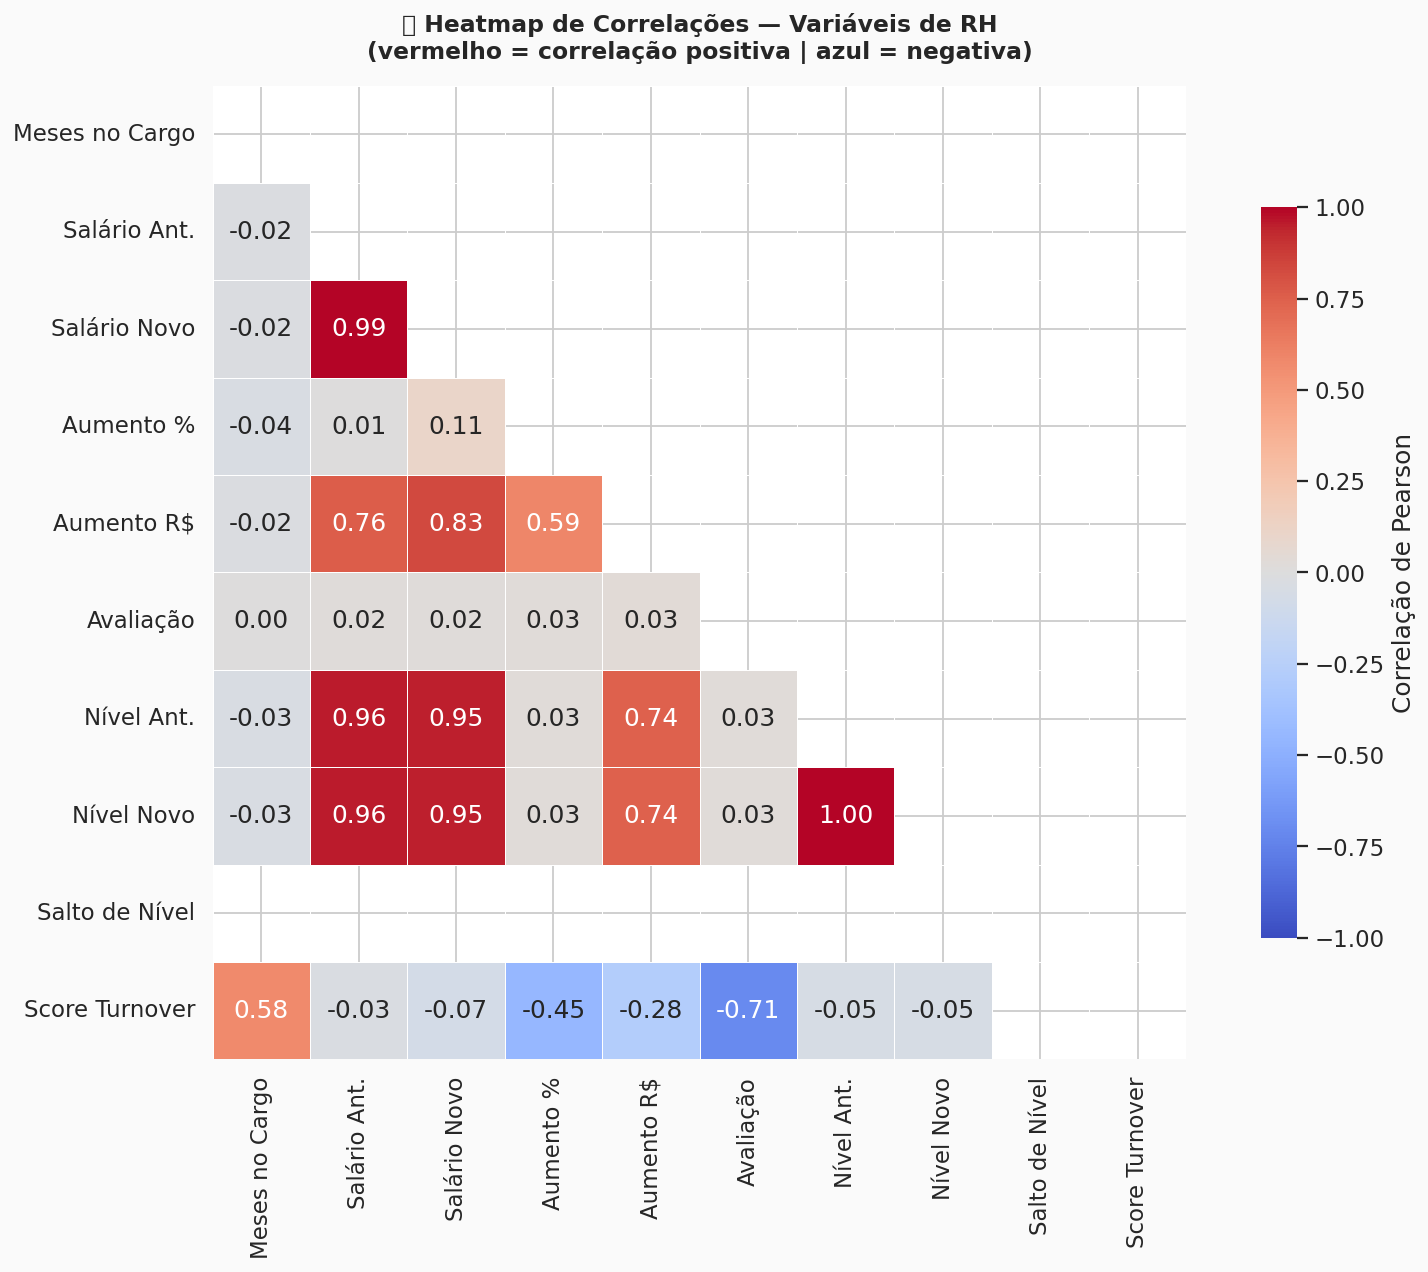

💾 Gráfico salvo: bloco7_heatmap_correlacoes.png

🔗 Correlações com Score de Turnover:
Avaliação        -0.707589
Aumento %        -0.447366
Aumento R$       -0.275588
Salário Novo     -0.071437
Nível Ant.       -0.049388
Nível Novo       -0.049388
Salário Ant.     -0.028984
Meses no Cargo    0.575239
Salto de Nível         NaN


In [31]:
"""
Visualiza as correlações entre todas as variáveis numéricas do dataset.
Correlações fortes podem indicar causalidade — mas sempre investigate antes
de tirar conclusões.
"""

colunas_numericas = [
    "meses_no_cargo_anterior", "salario_anterior", "salario_novo",
    "aumento_percentual", "aumento_real", "avaliacao_no_momento",
    "nivel_anterior", "nivel_novo", "salto_nivel", "score_turnover"
]

# Renomeia para labels mais legíveis no heatmap
labels_legíveis = {
    "meses_no_cargo_anterior": "Meses no Cargo",
    "salario_anterior": "Salário Ant.",
    "salario_novo": "Salário Novo",
    "aumento_percentual": "Aumento %",
    "aumento_real": "Aumento R$",
    "avaliacao_no_momento": "Avaliação",
    "nivel_anterior": "Nível Ant.",
    "nivel_novo": "Nível Novo",
    "salto_nivel": "Salto de Nível",
    "score_turnover": "Score Turnover",
}

corr_matrix = df_historico_promocoes[colunas_numericas].rename(columns=labels_legíveis).corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # oculta triângulo superior

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True, ax=ax,
    cbar_kws={"shrink": 0.75, "label": "Correlação de Pearson"}
)
ax.set_title("🔗 Heatmap de Correlações — Variáveis de RH\n"
             "(vermelho = correlação positiva | azul = negativa)",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("bloco7_heatmap_correlacoes.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico salvo: bloco7_heatmap_correlacoes.png")

# Destaca correlações fortes com score de turnover
corr_turnover = corr_matrix["Score Turnover"].drop("Score Turnover").sort_values()
print("\n🔗 Correlações com Score de Turnover:")
print(corr_turnover.to_string())

`BLOCO 8 — DASHBOARD EXECUTIVO (Texto + KPIs)`

In [33]:
custo_desligamento = 45_000
total_funcionarios = 1_200
turnover_atual = 0.19

total_desligamentos_ano = int(total_funcionarios * turnover_atual)
custo_total_ano = total_desligamentos_ano * custo_desligamento

n_alto_risco = (df_historico_promocoes["risco_turnover"] == "ALTO").sum()
pct_alto_risco_M = (df_historico_promocoes[(df_historico_promocoes["risco_turnover"]=="ALTO") & (df_historico_promocoes["sexo"]=="M")].shape[0] /
                    df_historico_promocoes[df_historico_promocoes["sexo"]=="M"].shape[0] * 100)
pct_alto_risco_F = (df_historico_promocoes[(df_historico_promocoes["risco_turnover"]=="ALTO") & (df_historico_promocoes["sexo"]=="F")].shape[0] /
                    df_historico_promocoes[df_historico_promocoes["sexo"]=="F"].shape[0] * 100)
dep_mais_risco = score_dep.index[0]

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║              RELATÓRIO EXECUTIVO — ANÁLISE DE PROMOÇÕES E TURNOVER          ║
╠══════════════════════════════════════════════════════════════════════════════╣""")

print(f"""
  📌 CONTEXTO
  ├── Total de funcionários: {total_funcionarios:,}
  ├── Taxa de turnover atual: {turnover_atual*100:.0f}%
  ├── Desligamentos estimados/ano: {total_desligamentos_ano}
  └── Custo anual estimado: R$ {custo_total_ano:,.0f}
""")

print(f"""  ⚖️  DISPARIDADE DE GÊNERO NO TEMPO DE PROMOÇÃO
  ├── Tempo médio — Homens (M): {media_M:.1f} meses
  ├── Tempo médio — Mulheres (F): {media_F:.1f} meses
  ├── Diferença: +{diferenca_pct:.1f}% a mais para mulheres
  └── Significância estatística: {'SIM (p < 0.05)' if p_valor_mw < 0.05 else 'NÃO (p ≥ 0.05)'}
""")

print(f"""  💰 EQUIDADE SALARIAL
  ├── Razão salarial F/M (antes da promoção): {razao_sal_ant:.3f}
  ├── Razão salarial F/M (após promoção): {razao_sal_nov:.3f}
  └── Conclusão: {"⚠️  GAP salarial identificado — requer investigação" if razao_sal_ant < 0.97 else "✅ Dentro de tolerância de ±3%"}
""")

print(f"""  🚨 RISCO DE TURNOVER
  ├── Funcionários com risco ALTO: {n_alto_risco} ({n_alto_risco/len(df_historico_promocoes)*100:.1f}% do histórico)
  ├── % risco alto — Homens: {pct_alto_risco_M:.1f}%
  ├── % risco alto — Mulheres: {pct_alto_risco_F:.1f}%
  └── Departamento de maior atenção: {dep_mais_risco} (score: {score_dep.iloc[0]:.3f})
""")

print(f"""  🔥 DEPARTAMENTO EM ALERTA (possível gestor tóxico)
  └── {perfil_dep.index[0]} — índice de atenção = {perfil_dep['indice_atencao'].iloc[0]:.3f}
      Avaliação média: {perfil_dep.loc[perfil_dep.index[0], 'avaliacao_media']:.2f} |
      Aumento médio: {perfil_dep.loc[perfil_dep.index[0], 'aumento_medio']:.2f}% |
      Tempo médio: {perfil_dep.loc[perfil_dep.index[0], 'meses_medio']:.1f} meses
""")

print("""  📋 RECOMENDAÇÕES
  1. Revisar política de promoção para eliminar viés de gênero no tempo de espera.
  2. Conduzir auditoria salarial controlada por cargo/departamento.
  3. Investigar o departamento de maior índice de atenção (entrevistas 1:1, eNPS).
  4. Implementar alerta automático: funcionário com score_turnover ≥ 0.65 → ação imediata.
  5. Monitorar trimestralmente o gap F/M em promoções e salários.

╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║              RELATÓRIO EXECUTIVO — ANÁLISE DE PROMOÇÕES E TURNOVER          ║
╠══════════════════════════════════════════════════════════════════════════════╣

  📌 CONTEXTO
  ├── Total de funcionários: 1,200
  ├── Taxa de turnover atual: 19%
  ├── Desligamentos estimados/ano: 228
  └── Custo anual estimado: R$ 10,260,000

  ⚖️  DISPARIDADE DE GÊNERO NO TEMPO DE PROMOÇÃO
  ├── Tempo médio — Homens (M): 22.9 meses
  ├── Tempo médio — Mulheres (F): 31.7 meses
  ├── Diferença: +38.7% a mais para mulheres
  └── Significância estatística: SIM (p < 0.05)

  💰 EQUIDADE SALARIAL
  ├── Razão salarial F/M (antes da promoção): 0.934
  ├── Razão salarial F/M (após promoção): 0.932
  └── Conclusão: ⚠️  GAP salarial identificado — requer investigação

  🚨 RISCO DE TURNOVER
  ├── Funcionários com risco ALTO: 9 (1.5% do histórico)
  ├── % risco alto — Homens: 0.3%
  ├── % risco alto — Mulheres: 2.8%
  └── Departamento d